In [2]:


import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

plt.style.use('ggplot')
sns.set_style('whitegrid')

print(" Libraries Imported ")

 Libraries Imported 


In [3]:
# 2. Load Processed Datasets

In this section, we load all the cleaned datasets from the `data/processed` folder into Pandas DataFrames for further analysis.

SyntaxError: invalid syntax (2136841019.py, line 3)

In [3]:


# Fund Master
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

# NAV History
nav_history = pd.read_csv("../data/processed/02_nav_history_clean.csv")

# AUM by Fund House
aum_history = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

# Monthly SIP Inflows
monthly_sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")

# Category Inflows
category_inflows = pd.read_csv("../data/processed/05_category_inflows_clean.csv")

# Industry Folio Count
folio_count = pd.read_csv("../data/processed/06_industry_folio_count_clean.csv")

# Investor Transactions
investor_transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

# Portfolio Holdings
portfolio_holdings = pd.read_csv("../data/processed/09_portfolio_holdings_clean.csv")

print(" All required datasets loaded successfully!")

 All required datasets loaded successfully!


In [4]:
# Create a dictionary of datasets

datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM History": aum_history,
    "Monthly SIP Inflows": monthly_sip,
    "Category Inflows": category_inflows,
    "Industry Folio Count": folio_count,
    "Investor Transactions": investor_transactions,
    "Portfolio Holdings": portfolio_holdings
}

# Display dataset summary
summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Fund Master,40,15
1,NAV History,46000,3
2,AUM History,90,5
3,Monthly SIP Inflows,48,6
4,Category Inflows,144,3
5,Industry Folio Count,21,6
6,Investor Transactions,32778,13
7,Portfolio Holdings,322,8


In [5]:
# Display first 5 rows of each dataset

for name, df in datasets.items():
    print("=" * 80)
    print(name)
    print("=" * 80)
    display(df.head())

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


NAV History


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


AUM History


...

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


Investor Transactions


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


Portfolio Holdings


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [6]:
# Display dataset information

print("Shape:", nav_history.shape)

print("\nColumn Names:")
print(nav_history.columns.tolist())

print("\nData Types:")
print(nav_history.dtypes)

Shape: (46000, 3)

Column Names:
['amfi_code', 'date', 'nav']

Data Types:
amfi_code      int64
date          object
nav          float64
dtype: object


In [7]:


nav_history.isnull().sum()

amfi_code    0
date         0
nav          0
dtype: int64

In [8]:
nav_history.head(10)

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
5,100016,2022-01-10,510.7136
6,100016,2022-01-11,513.5542
7,100016,2022-01-12,512.3195
8,100016,2022-01-13,510.2445
9,100016,2022-01-14,514.3636


In [9]:
print(nav_history.columns.tolist())


['amfi_code', 'date', 'nav']


In [10]:
## 4.1.1 Merge NAV History with Fund Master

The NAV history dataset contains only the AMFI code for each scheme. To create meaningful visualizations, it is merged with the Fund Master dataset to retrieve the corresponding scheme names and other fund details.

SyntaxError: invalid syntax (200297140.py, line 3)

In [11]:

print(fund_master.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


In [12]:
# ==========================================================
# Merge NAV History with Fund Master
# ==========================================================

nav_data = pd.merge(
    nav_history,
    fund_master,
    on="amfi_code",
    how="left"
)

print("Shape after merging:", nav_data.shape)

nav_data.head()

Shape after merging: (46000, 17)


,amfi_code,date,nav,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,100016,2022-01-03,520.4608,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
1,100016,2022-01-04,515.0971,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
2,100016,2022-01-05,521.7239,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
3,100016,2022-01-06,515.7880,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01
4,100016,2022-01-07,515.1639,HDFC Mutual Fund,HDFC Top 100 Fund - Regular Plan - Growth,Equity,Large Cap,Regular,1996-09-11,NIFTY 100 TRI,1.55,1.0,500,1000,Rahul Baijal,Moderate,EC01


In [13]:
# ==========================================================
# Data Preparation
# ==========================================================

# Convert date column to datetime
nav_data["date"] = pd.to_datetime(nav_data["date"])

# Sort values
nav_data = nav_data.sort_values(["scheme_name", "date"])

# Filter data between 2022 and 2026
nav_data = nav_data[
    (nav_data["date"] >= "2022-01-01") &
    (nav_data["date"] <= "2026-12-31")
]

print("Filtered Shape:", nav_data.shape)

nav_data.head()

Filtered Shape: (46000, 17)


,amfi_code,date,nav,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
3450,101206,2022-01-03,305.0996,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01
3451,101206,2022-01-04,305.4514,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01
3452,101206,2022-01-05,306.6324,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01
3453,101206,2022-01-06,305.9800,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01
3454,101206,2022-01-07,304.0480,Aditya Birla Sun Life MF,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,Regular,2002-08-30,NIFTY 100 TRI,1.6,1.0,500,1000,Mahesh Patil,Moderate,EC01


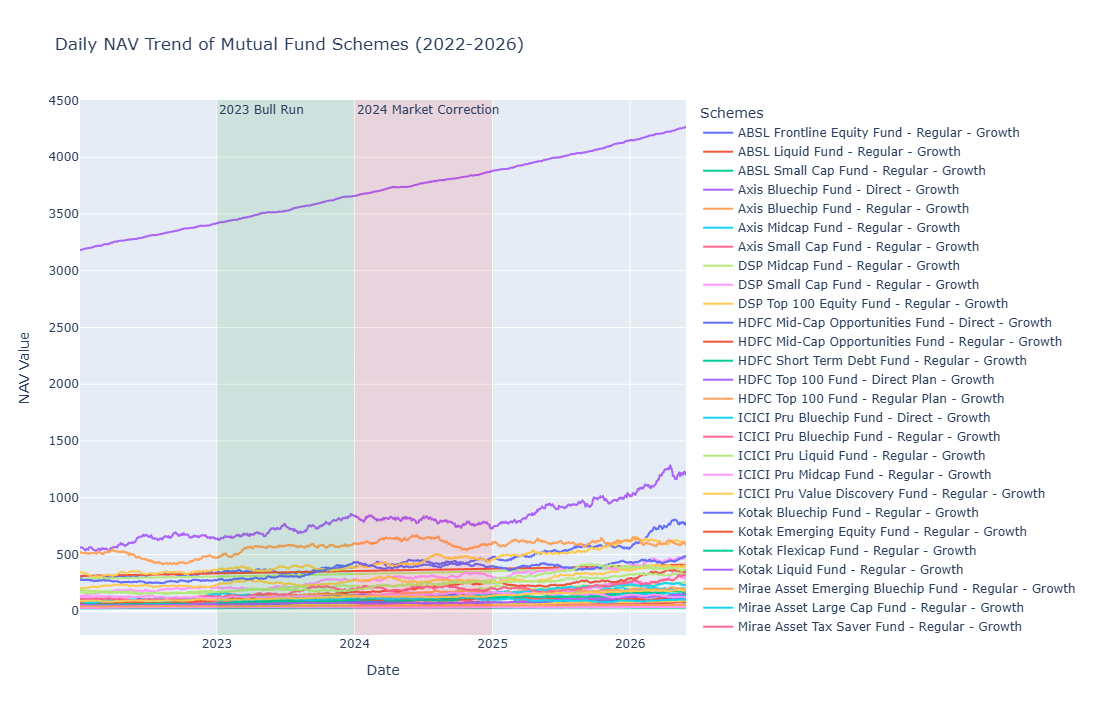

In [14]:
import plotly.express as px

# Create interactive NAV trend chart
fig = px.line(
    nav_data,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022-2026)",
    labels={
        "date": "Date",
        "nav": "NAV Value",
        "scheme_name": "Scheme"
    }
)

# Add 2023 Bull Run highlight
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.1,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Add 2024 Correction highlight
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.1,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

# Improve layout
fig.update_layout(
    height=700,
    width=1200,
    hovermode="x unified",
    legend_title_text="Schemes"
)

fig.show()

In [15]:
fig.write_html(
    "../reports/charts/NAV_daily_trend.html"
)

In [16]:
pip install kaleido

Note: you may need to restart the kernel to use updated packages.


In [18]:
fig.write_image(
    "../reports/charts/NAV_daily_trend.png"
)

In [19]:
import os

os.listdir("../data/processed")

['01_fund_master_clean.csv',
 '02_nav_history_clean.csv',
 '03_aum_by_fund_house_clean.csv',
 '04_monthly_sip_inflows_clean.csv',
 '05_category_inflows_clean.csv',
 '06_industry_folio_count_clean.csv',
 '07_scheme_performance_clean.csv',
 '08_investor_transactions_clean.csv',
 '09_portfolio_holdings_clean.csv',
 '10_benchmark_indices_clean.csv']

In [20]:


aum_data = pd.read_csv(
    "../data/processed/03_aum_by_fund_house_clean.csv"
)

aum_data.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [21]:
aum_data.shape

(90, 5)

In [22]:
aum_data.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

In [23]:
aum_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     object 
 1   fund_house      90 non-null     object 
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 3.6+ KB


In [24]:
aum_data.head(10)

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168
5,2022-03-31,Aditya Birla Sun Life MF,2.78,278000,199
6,2022-03-31,Axis Mutual Fund,2.50,250000,95
7,2022-03-31,UTI Mutual Fund,2.30,230000,142
8,2022-03-31,Mirae Asset MF,1.05,105000,56
9,2022-03-31,DSP Mutual Fund,1.10,110000,88


In [25]:
aum_data.describe()

,aum_lakh_crore,aum_crore,num_schemes
count,90.000000,9.000000e+01,90.000000
mean,4.352889,4.352889e+05,152.200000
std,2.734328,2.734328e+05,52.108832
min,1.050000,1.050000e+05,56.000000
25%,2.525000,2.525000e+05,95.000000
50%,3.450000,3.450000e+05,172.500000
75%,5.675000,5.675000e+05,195.000000
max,12.500000,1.250000e+06,216.000000


<Axes: >

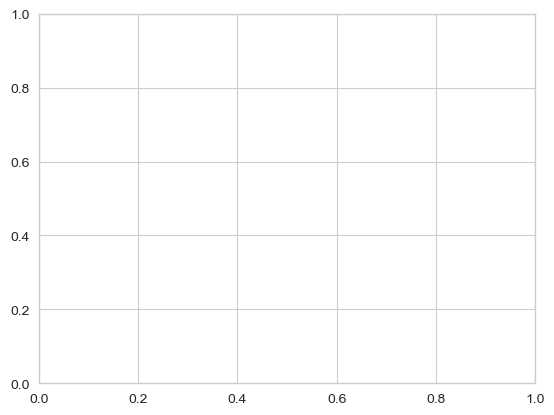

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.barplot()

In [29]:
aum_data = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

aum_data.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [30]:
aum_data.columns

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

In [31]:
aum_data.shape

(90, 5)

In [32]:

aum_data["date"] = pd.to_datetime(aum_data["date"])

aum_data["year"] = aum_data["date"].dt.year
aum_filtered = aum_data[
    (aum_data["year"] >= 2022) &
    (aum_data["year"] <= 2025)
]

print("Filtered Shape:", aum_filtered.shape)

aum_filtered.head()

Filtered Shape: (90, 6)


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [33]:
aum_filtered["year"].value_counts()

year
2024    30
2022    20
2023    20
2025    20
Name: count, dtype: int64

In [34]:
aum_yearly = (
    aum_filtered
    .groupby(["fund_house", "year"])["aum_lakh_crore"]
    .max()
    .reset_index()
)

aum_yearly.head()

,fund_house,year,aum_lakh_crore
0,Aditya Birla Sun Life MF,2022,2.85
1,Aditya Birla Sun Life MF,2023,3.08
2,Aditya Birla Sun Life MF,2024,3.84
3,Aditya Birla Sun Life MF,2025,4.60
4,Axis Mutual Fund,2022,2.50


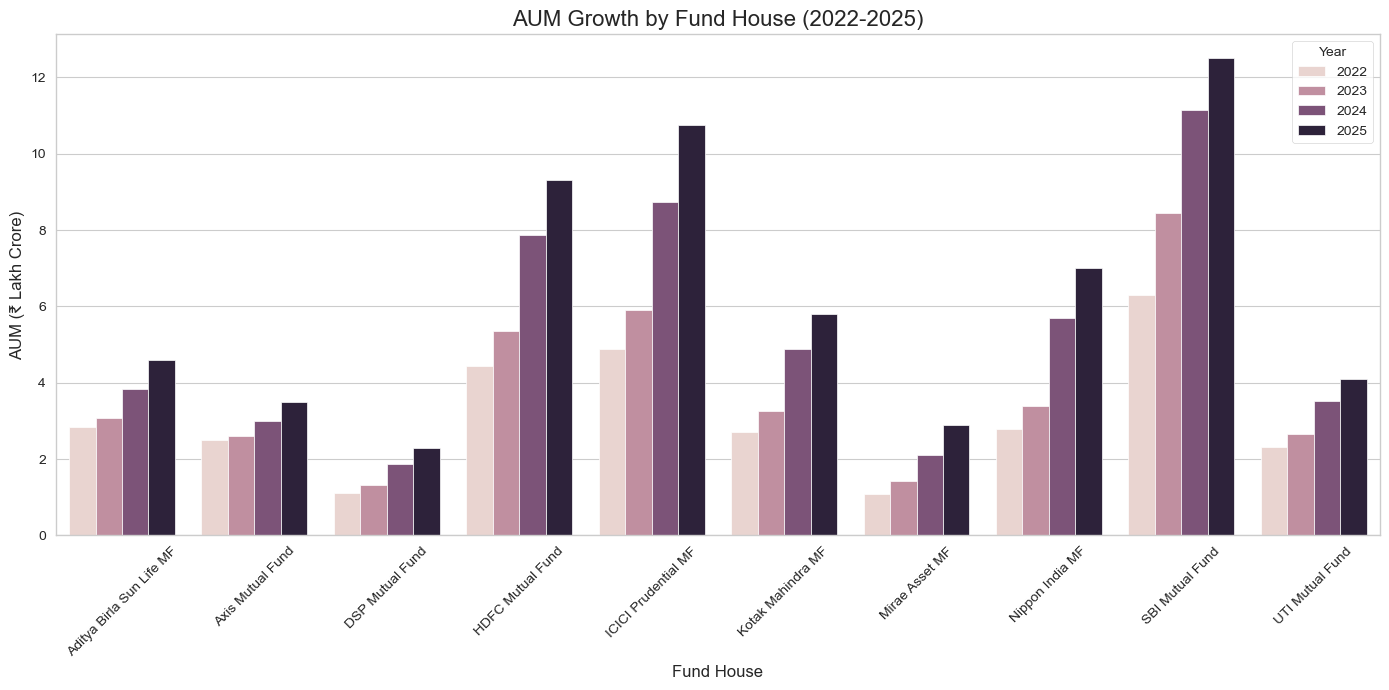

In [35]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)",
    fontsize=16
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45)

plt.legend(
    title="Year"
)

plt.tight_layout()

plt.show()

In [36]:
aum_yearly[
    aum_yearly["fund_house"].str.contains("SBI", case=False)
]

,fund_house,year,aum_lakh_crore
32,SBI Mutual Fund,2022,6.30
33,SBI Mutual Fund,2023,8.45
34,SBI Mutual Fund,2024,11.14
35,SBI Mutual Fund,2025,12.50


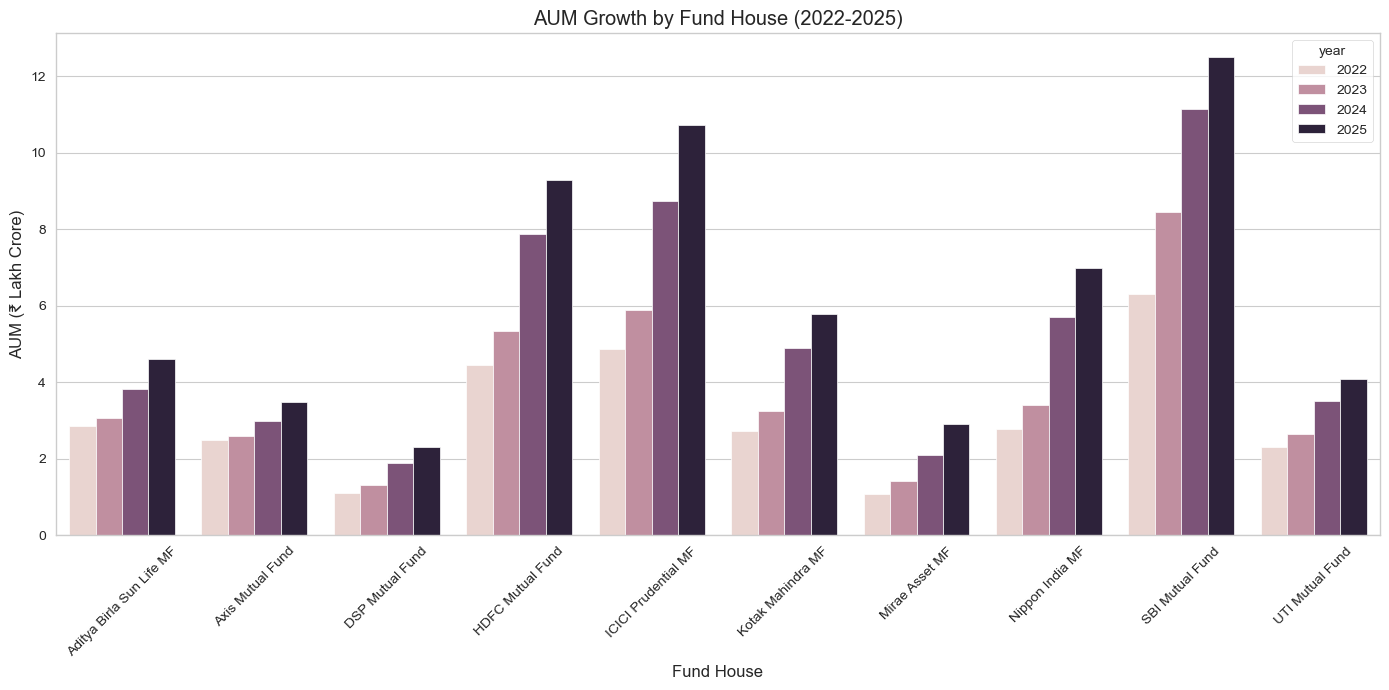

In [37]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)"
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [38]:
aum_filtered.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [39]:
# ==========================================================
# Aggregate AUM by Fund House and Year
# ==========================================================

aum_yearly = (
    aum_filtered
    .groupby(["fund_house", "year"])["aum_lakh_crore"]
    .max()
    .reset_index()
)

aum_yearly.head(10)

,fund_house,year,aum_lakh_crore
0,Aditya Birla Sun Life MF,2022,2.85
1,Aditya Birla Sun Life MF,2023,3.08
2,Aditya Birla Sun Life MF,2024,3.84
3,Aditya Birla Sun Life MF,2025,4.60
4,Axis Mutual Fund,2022,2.50
5,Axis Mutual Fund,2023,2.60
6,Axis Mutual Fund,2024,3.00
7,Axis Mutual Fund,2025,3.50
8,DSP Mutual Fund,2022,1.12
9,DSP Mutual Fund,2023,1.32


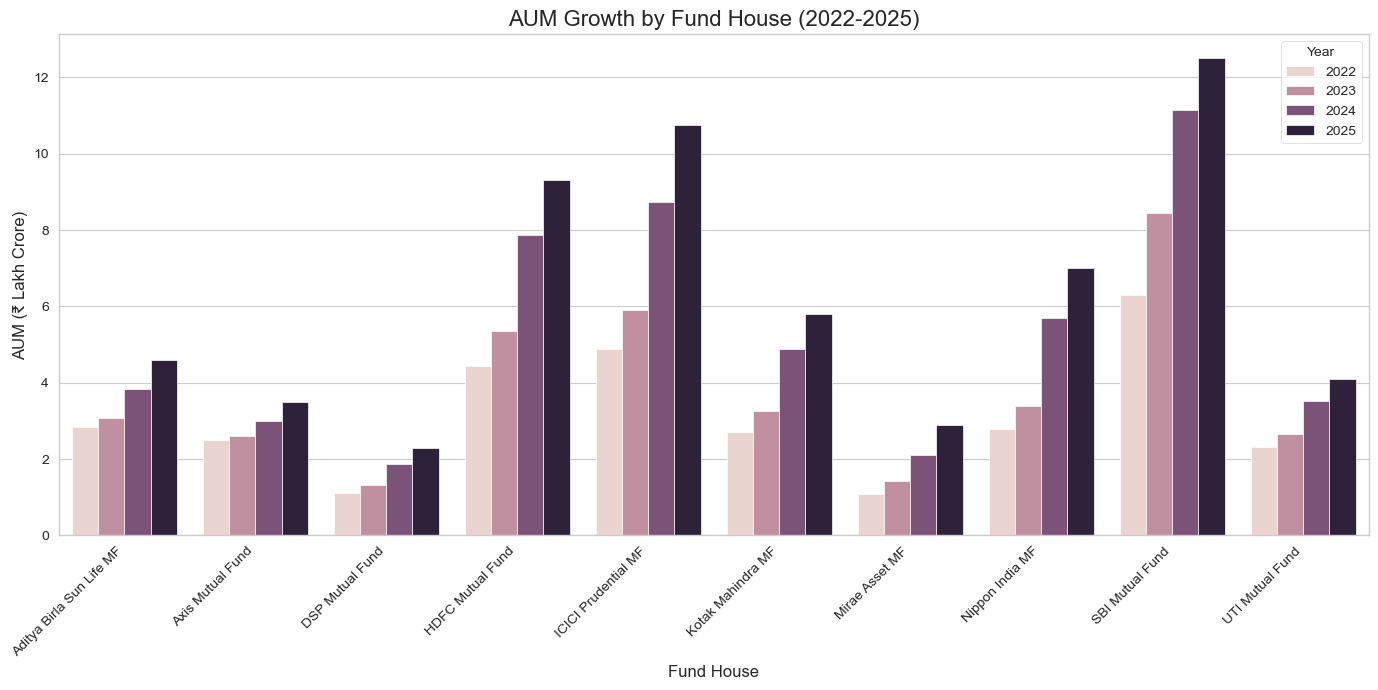

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)",
    fontsize=16
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Year"
)

plt.tight_layout()

plt.show()

In [44]:
aum_yearly[
    aum_yearly["fund_house"].str.contains("SBI", case=False)
]

,fund_house,year,aum_lakh_crore
32,SBI Mutual Fund,2022,6.30
33,SBI Mutual Fund,2023,8.45
34,SBI Mutual Fund,2024,11.14
35,SBI Mutual Fund,2025,12.50


In [46]:
aum_yearly["year"] = aum_yearly["year"].astype(str)

aum_yearly["aum_lakh_crore"] = pd.to_numeric(
    aum_yearly["aum_lakh_crore"],
    errors="coerce"
)

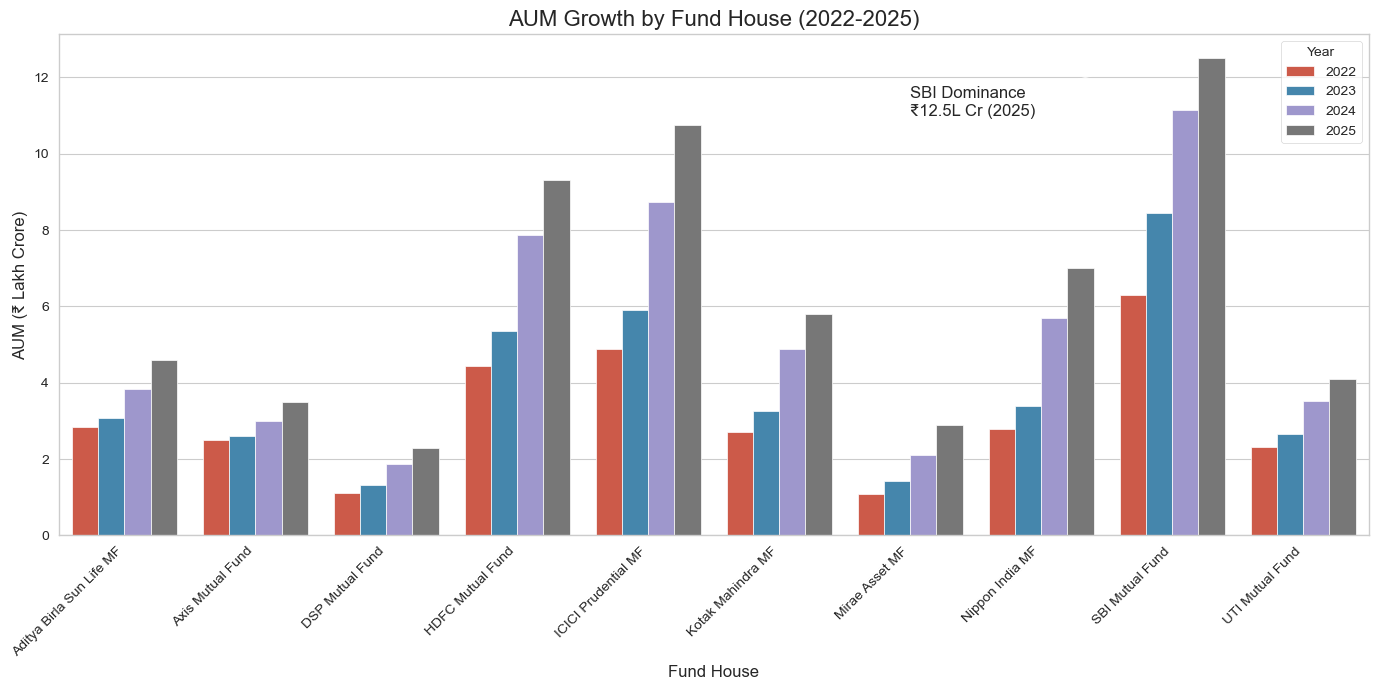

In [48]:
plt.annotate(
    "SBI Dominance\n₹12.5L Cr (2025)",
    xy=(8,12.5),
    xytext=(6,11),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=12
)

In [49]:
aum_yearly["fund_house"].unique()

array(['Aditya Birla Sun Life MF', 'Axis Mutual Fund', 'DSP Mutual Fund',
       'HDFC Mutual Fund', 'ICICI Prudential MF', 'Kotak Mahindra MF',
       'Mirae Asset MF', 'Nippon India MF', 'SBI Mutual Fund',
       'UTI Mutual Fund'], dtype=object)

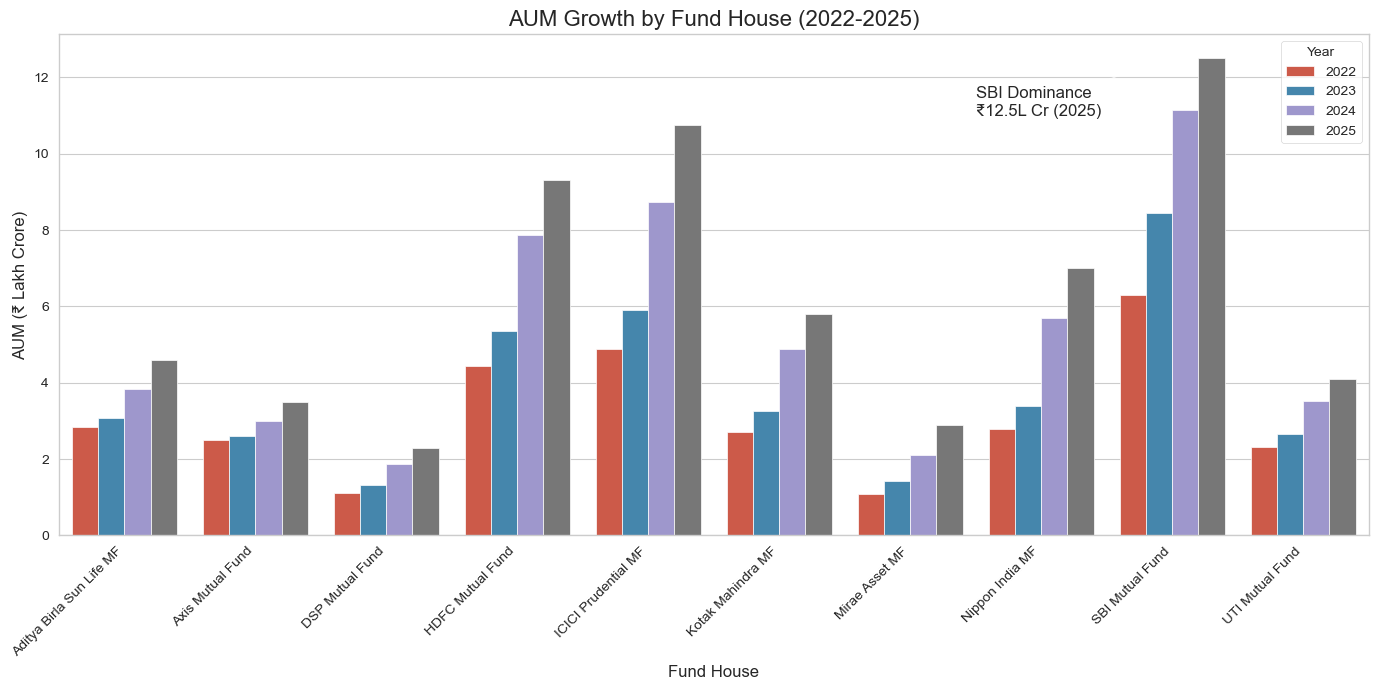

In [51]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_yearly,
    x="fund_house",
    y="aum_lakh_crore",
    hue="year"
)

plt.title(
    "AUM Growth by Fund House (2022-2025)",
    fontsize=16
)

plt.xlabel("Fund House")
plt.ylabel("AUM (₹ Lakh Crore)")

plt.xticks(rotation=45, ha="right")


# SBI Highlight
plt.annotate(
    "SBI Dominance\n₹12.5L Cr (2025)",
    xy=(8,12.5),
    xytext=(6.5,11),
    arrowprops=dict(
        arrowstyle="->"
    ),
    fontsize=12
)

plt.legend(title="Year")

plt.tight_layout()

plt.show()